# Generation Results

Compile the generation results of the experiment "nq_open_with_reference" into a single file for easier analysis.

## Setup & Configuration

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import gc
from pathlib import Path
from tqdm import tqdm
from datetime import datetime

from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed

set_random_seed(42)

INFO 05-16 18:59:38 [__init__.py:216] Automatically detected platform cuda.


In [2]:
GENERATIONS_BASE_PATH="runs"
EXPERIMENTS = ["qwen", "qwen_default", "llama", "llama_default"]
# EXPERIMENTS = ["llama"]
# METRICS = ["rouge_l", "squad_v2_best_exact", "squad_v2_best_f1"] 
METRICS = ["squad_v2_best_exact", "squad_v2_best_f1"] 
GENERATION_PATTERNS = ["rag", "zeroshot", "naive", "pairwise_rag_judge", "pairwise_zeroshot_judge", "voting_naive"]  
CACHE_ENABLED = False
RESULTS_CACHE_PATH = "notebooks/results/generation_results_compiled.feather"

# Metric name mapping for storytelling clarity
METRIC_NAMES = {
    "squad_v2_best_exact": "Exact Match (EM)",
    "squad_v2_best_f1": "F1 Score",
    "rouge_l": "ROUGE-L"
}

# Experiment name mapping for display labels
EXPERIMENT_NAMES = {
    "qwen": "qwen_extraction",
    "qwen_default": "qwen_instruction",
    "llama": "llama_extraction",
    "llama_default": "llama_instruction"
}

# Visualization config - Colorful palette for clarity
GENERATION_METHOD_COLORS = {
    "rag": "#ffff99",                   # Yellow
    "zeroshot": "#386cb0",             # Blue
    "naive": "#1b9e77",                # Green
    "pairwise_rag_judge": "#d95f02",   # Orange
    "pairwise_zeroshot_judge": "#7570b3", # Purple
    "voting_naive": "#e7298a"           # Light Red
}
# Fallback color palette
COLOR_PALETTE = sns.color_palette("husl", n_colors=8)

### Discovery & Available Folders

In [3]:
# Discover available experiment folders and generation files
def discover_available_runs(base_path):
    """List all available experiment runs and their generation files."""
    available = {}
    if not os.path.exists(base_path):
        print(f"Base path '{base_path}' does not exist")
        return available
    
    for exp_folder in os.listdir(base_path):
        exp_path = os.path.join(base_path, exp_folder)
        if os.path.isdir(exp_path):
            gen_path = os.path.join(exp_path, "generations")
            if os.path.exists(gen_path):
                gen_files = [f for f in os.listdir(gen_path) if f.endswith(".json")]
                available[exp_folder] = gen_files
    
    return available

available_runs = discover_available_runs(GENERATIONS_BASE_PATH)
print("Available experiment runs and generation files:")
for exp, files in available_runs.items():
    print(f"  {exp}: {files}")

Available experiment runs and generation files:
  llama_default: ['naive.json', 'zeroshot.json', 'pairwise_rag_judge.json', 'pairwise_zeroshot_judge.json', 'rag.json', 'voting_naive.json']
  llama: ['rag.json', 'pairwise_zeroshot_judge.json', 'naive.json', 'pairwise_rag_judge.json', 'zeroshot.json', 'voting_naive.json']
  qwen: ['pairwise_rag_judge.json', 'naive.json', 'pairwise_zeroshot_judge.json', 'voting_naive.json', 'zeroshot.json', 'rag.json']
  qwen_default: ['rag.json', 'pairwise_zeroshot_judge.json', 'zeroshot.json', 'pairwise_rag_judge.json', 'voting_naive.json', 'naive.json']


In [4]:
# Helper function to extract generation method from filename
def extract_generation_method(filename):
    """Extract generation method from filename (e.g., 'rag.json' -> 'rag')."""
    return filename.replace(".json", "")

# Helper function to check if generation file matches any pattern
def matches_pattern(filename, patterns):
    """Check if filename matches any of the patterns."""
    for pattern in patterns:
        if pattern in filename:
            return pattern


In [5]:
# Metric-specific formatting function
def format_metric_value(metric, value):
    """Format metric values with appropriate precision based on metric type.
    
    - Exact Match: 0-100 scale with 1 decimal place (e.g., 40.2)
    - F1 Score: 0-1 scale with 3 decimal places (e.g., 0.402)
    """
    if metric == "squad_v2_best_exact":
        # Scale to 0-100 and format with 1 decimal place
        return f"{value * 100:.1f}"
    elif metric == "squad_v2_best_f1":
        # Format with 3 decimal places
        return f"{value:.3f}"
    else:
        # Default formatting
        return f"{value:.4f}"


## Data Loading & Metric Calculation (Only Llama)

In [6]:

available_runs = discover_available_runs(GENERATIONS_BASE_PATH)
print("Available experiment runs and generation files:")
for exp, files in available_runs.items():
    print(f"  {exp}: {files}")

# Load from cache if available
LOAD_FROM_CACHE = CACHE_ENABLED and os.path.exists(RESULTS_CACHE_PATH)

if LOAD_FROM_CACHE:
    print(f"Loading cached results from {RESULTS_CACHE_PATH}...")
    generations_results = pl.read_ipc(RESULTS_CACHE_PATH)
    print(f"Loaded {len(generations_results)} rows")
else:
    print(f"Calculating metrics for experiments: {EXPERIMENTS}")
    print(f"Metrics: {METRICS}")
    
    dfs_generations = []
    
    # Loop over experiments
    for exp in EXPERIMENTS:
        exp_path = os.path.join(GENERATIONS_BASE_PATH, exp)
        gen_path = os.path.join(exp_path, "generations")
        questions_path = "../../data/nq_open/processed/dev.feather"
        
        # Verify paths exist
        if not os.path.exists(gen_path):
            print(f"Generation path not found: {gen_path}")
            continue
        if not os.path.exists(questions_path):
            print(f"Questions path not found: {questions_path}")
            continue
        
        # Loop over generation files
        for gen_file in sorted(os.listdir(gen_path)):
            pattern_match = matches_pattern(gen_file, GENERATION_PATTERNS)
            if not gen_file.endswith(".json") or pattern_match is None:
                continue
        
            generation_method = extract_generation_method(gen_file)
            gen_file_path = os.path.join(gen_path, gen_file)
            
            print(f"Processing: {exp}/{gen_file}")
            
            try:
                # Calculate metrics using the utils function
                result_df = calculate_agg_metric(
                    metrics=METRICS,
                    generation_path=gen_file_path,
                    reference_path=questions_path,
                    saving_path=None
                )
                
                # Add experiment and generation method columns
                result_df = result_df.with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(generation_method).alias("generation_method"),
                    pl.lit(pattern_match).alias("generation_pattern")
                ])
                
                dfs_generations.append(result_df)                
            except Exception as e:
                print(f"Error: {e}")
                continue
    
    # Concatenate all results
    if dfs_generations:
        generations_results = pl.concat(dfs_generations)
        
        # Cache results
        if CACHE_ENABLED:
            generations_results.write_ipc(RESULTS_CACHE_PATH)
            print(f"Results cached to {RESULTS_CACHE_PATH}")
    else:
        print("No results to process")
        generations_results = None

Available experiment runs and generation files:
  llama_default: ['naive.json', 'zeroshot.json', 'pairwise_rag_judge.json', 'pairwise_zeroshot_judge.json', 'rag.json', 'voting_naive.json']
  llama: ['rag.json', 'pairwise_zeroshot_judge.json', 'naive.json', 'pairwise_rag_judge.json', 'zeroshot.json', 'voting_naive.json']
  qwen: ['pairwise_rag_judge.json', 'naive.json', 'pairwise_zeroshot_judge.json', 'voting_naive.json', 'zeroshot.json', 'rag.json']
  qwen_default: ['rag.json', 'pairwise_zeroshot_judge.json', 'zeroshot.json', 'pairwise_rag_judge.json', 'voting_naive.json', 'naive.json']
Calculating metrics for experiments: ['qwen', 'qwen_default', 'llama', 'llama_default']
Metrics: ['squad_v2_best_exact', 'squad_v2_best_f1']
Processing: qwen/naive.json
Calculating squad_v2_best_exact...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Calculating squad_v2_best_f1...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Processing: qwen/pairwise_rag_judge.json
Calculating squad_v2_best_exact...


...

Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Processing: llama_default/zeroshot.json
Calculating squad_v2_best_exact...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Calculating squad_v2_best_f1...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


In [7]:
# Inspect the results structure
if generations_results is not None:
    print(f"Shape: {generations_results.shape}")
    print(f"Columns: {generations_results.columns}")
    print("\nSample rows:")
    print(generations_results.head(2))

Shape: (173280, 6)
Columns: ['idx', 'value', 'metric', 'experiment', 'generation_method', 'generation_pattern']

Sample rows:
shape: (2, 6)
┌─────┬───────┬─────────────────────┬────────────┬───────────────────┬────────────────────┐
│ idx ┆ value ┆ metric              ┆ experiment ┆ generation_method ┆ generation_pattern │
│ --- ┆ ---   ┆ ---                 ┆ ---        ┆ ---               ┆ ---                │
│ i64 ┆ f32   ┆ str                 ┆ str        ┆ str               ┆ str                │
╞═════╪═══════╪═════════════════════╪════════════╪═══════════════════╪════════════════════╡
│ 0   ┆ 1.0   ┆ squad_v2_best_exact ┆ qwen       ┆ naive             ┆ naive              │
│ 1   ┆ 0.0   ┆ squad_v2_best_exact ┆ qwen       ┆ naive             ┆ naive              │
└─────┴───────┴─────────────────────┴────────────┴───────────────────┴────────────────────┘


## Visualizations

### Summary Statistics by Metric & Generation Method

In [8]:
if generations_results is not None:
    # Compute aggregated statistics by metric and generation method
    summary_stats = (
        generations_results
        .group_by(["metric", "generation_method"])
        .agg([
            pl.col("value").mean().alias("mean"),
            pl.col("value").std().alias("std"),
            pl.col("value").count().alias("count")
        ])
        .with_columns([
            pl.col("metric").map_elements(lambda x: METRIC_NAMES.get(x, x)).alias("metric_display")
        ])
        .sort("metric", "mean", descending=[False, True])
    )
    
    # Format for display with metric-specific precision
    summary_stats_display = summary_stats.clone()
    for i, row in enumerate(summary_stats.iter_rows(named=True)):
        formatted_mean = format_metric_value(row['metric'], row['mean'])
        formatted_std = format_metric_value(row['metric'], row['std'])
        summary_stats_display[i, "mean"] = formatted_mean
        summary_stats_display[i, "std"] = formatted_std
    
    print("\n📊 Summary Statistics by Metric & Generation Method:")
    display_cols = ["metric_display", "generation_method", "mean", "std", "count"]
    display_df = summary_stats_display.select(display_cols).to_pandas()
    print(display_df.to_string(index=False))


📊 Summary Statistics by Metric & Generation Method:
  metric_display       generation_method      mean       std  count
Exact Match (EM)            voting_naive 26.799999 44.299999  14440
Exact Match (EM)                     rag 26.700001 44.299999  14440
Exact Match (EM)                   naive 25.000000 43.299999  14440
Exact Match (EM) pairwise_zeroshot_judge 21.100000 40.799999  14440
Exact Match (EM)      pairwise_rag_judge 18.299999 38.599998  14440
Exact Match (EM)                zeroshot 10.500000 30.700001  14440
        F1 Score                     rag  0.396000  0.422000  14440
        F1 Score            voting_naive  0.390000  0.425000  14440
        F1 Score                   naive  0.367000  0.420000  14440
        F1 Score pairwise_zeroshot_judge  0.324000  0.405000  14440
        F1 Score      pairwise_rag_judge  0.291000  0.392000  14440
        F1 Score                zeroshot  0.212000  0.334000  14440


### Multi-Metric Bar Charts

In [9]:
# if generations_results is not None:
#     # Create bar charts for each metric grouped by experiment and generation method
#     # Following Storytelling with Data principles: minimize clutter, emphasize data
#     sns.set_theme(style="white")
    
#     for metric in METRICS:
#         metric_display = METRIC_NAMES.get(metric, metric)
        
#         # Filter data for this metric
#         metric_data = (
#             generations_results
#             .filter(pl.col("metric") == metric)
#             .group_by(["experiment", "generation_method"])
#             .agg([
#                 pl.col("value").mean().alias("mean"),
#                 pl.col("value").std().alias("std")
#             ])
#             .sort("mean", descending=True)
#             .to_pandas()
#         )
        
#         if len(metric_data) == 0:
#             print(f"⚠️  No data for metric: {metric}")
#             continue
        
#         # Create figure
#         fig, ax = plt.subplots(figsize=(14, 6))
        
#         # Create barplot grouped by generation method with hue by experiment
#         palette_map = {gen: PASTEL_COLORS.get(gen, PASTEL_PALETTE[i % len(PASTEL_PALETTE)]) 
#                        for i, gen in enumerate(metric_data["generation_method"].unique())}
        
#         sns.barplot(
#             data=metric_data,
#             x="experiment",
#             y="mean",
#             hue="generation_method",
#             palette=palette_map,
#             ax=ax,
#             ci=None
#         )
        
#         # Add value labels on top of bars with metric-specific formatting
#         for container in ax.containers:
#             labels = [format_metric_value(metric, v) for v in container.datavalues]
#             ax.bar_label(container, labels=labels, padding=3, fontsize=9, color="#333", weight="bold")
        
#         # Storytelling with Data styling: clean, focused, minimal clutter
#         ax.set_title(f"{metric_display} Performance by Experiment", fontsize=16, fontweight="bold", pad=20)
#         ax.set_xlabel("Experiment", fontsize=12, fontweight="semibold")
#         ax.set_ylabel(f"{metric_display}", fontsize=12, fontweight="semibold")
#         ax.set_ylim(0, metric_data["mean"].max() * 1.12)
        
#         # Remove top and right spines for cleaner look
#         ax.spines["top"].set_visible(False)
#         ax.spines["right"].set_visible(False)
        
#         # Minimal gridlines - only horizontal, light
#         ax.grid(axis="y", alpha=0.2, linestyle="--", linewidth=0.7)
#         ax.set_axisbelow(True)
        
#         ax.legend(title="Generation Method", title_fontsize=11, fontsize=10, loc="upper right", framealpha=0.95)
        
#         plt.xticks(rotation=45, ha="right", fontsize=11)
#         plt.yticks(fontsize=11)
#         plt.tight_layout()
#         plt.show()

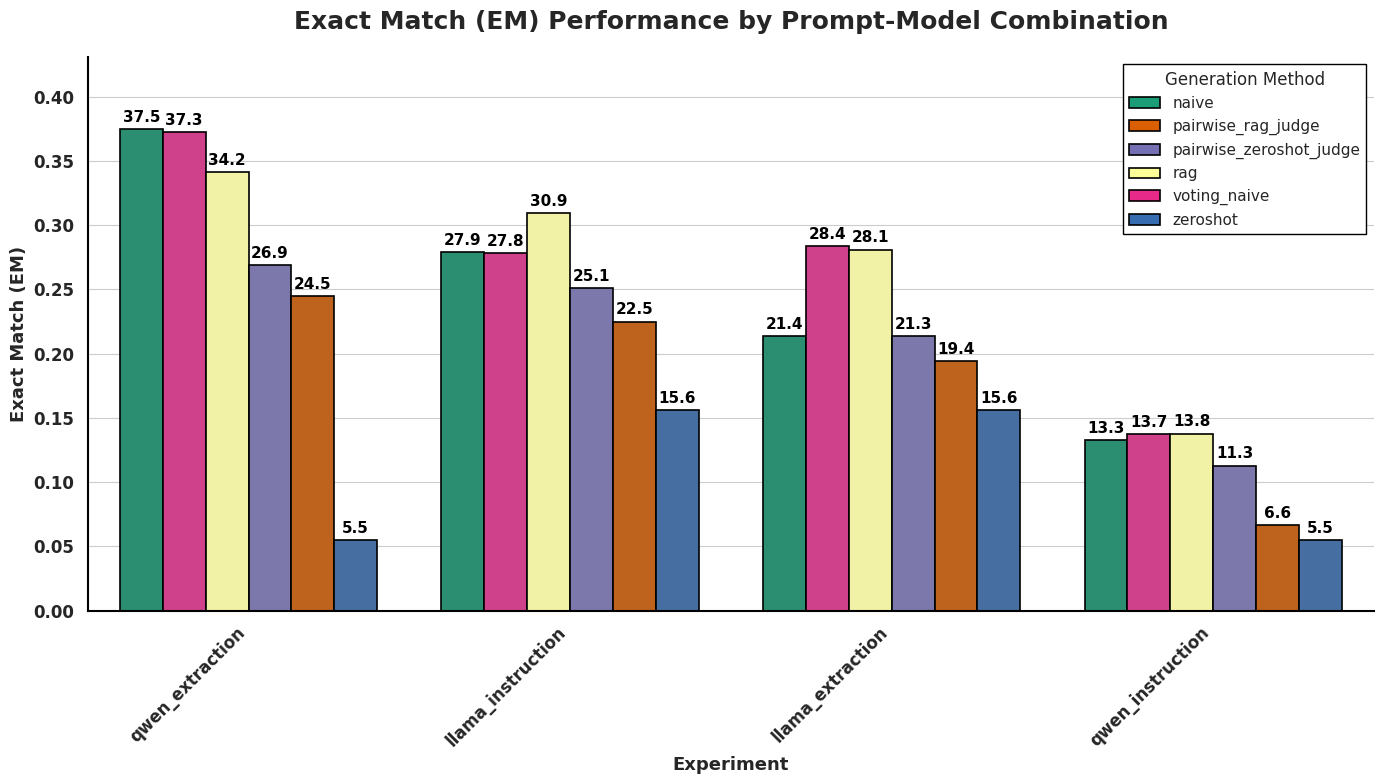

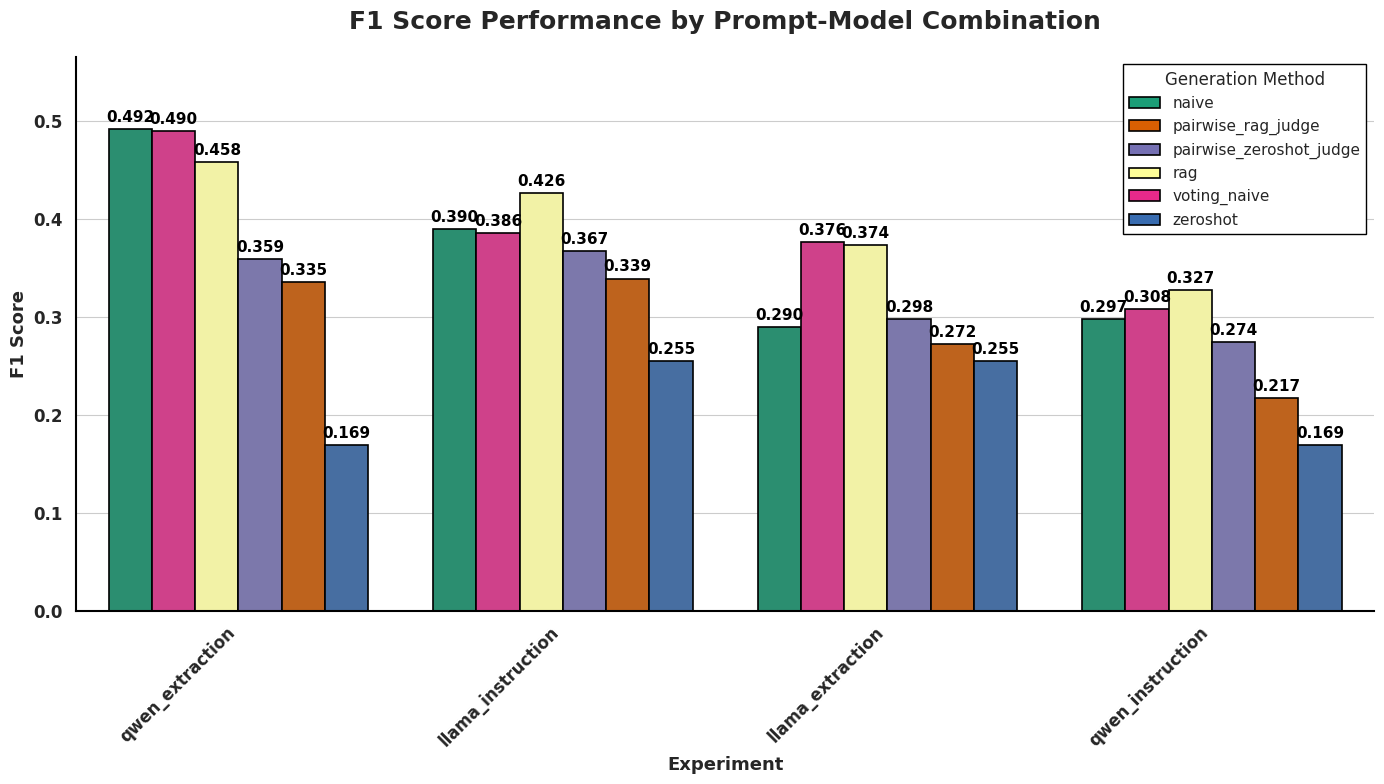

In [9]:
if generations_results is not None:
    # Create bar charts for each metric grouped by experiment and generation method
    # Thesis-ready: B&W grayscale with patterns for printability
    sns.set_theme(style="white")
    
    for metric in METRICS:
        metric_display = METRIC_NAMES.get(metric, metric)
        
        # Filter data for this metric
        metric_data = (
            generations_results
            .filter(pl.col("metric") == metric)
            .group_by(["experiment", "generation_method"])
            .agg([
                pl.col("value").mean().alias("mean"),
                pl.col("value").std().alias("std")
            ])
            .to_pandas()
        )
        
        # Map experiment names to display names
        metric_data["experiment"] = metric_data["experiment"].map(lambda x: EXPERIMENT_NAMES.get(x, x))
        metric_data = metric_data.sort_values("mean", ascending=False)
        
        if len(metric_data) == 0:
            print(f"⚠️  No data for metric: {metric}")
            continue
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Create barplot with colorful palette
        palette_map = {gen: GENERATION_METHOD_COLORS.get(gen, COLOR_PALETTE[i % len(COLOR_PALETTE)]) 
                       for i, gen in enumerate(metric_data["generation_method"].unique())}
        
        sns.barplot(
            data=metric_data,
            x="experiment",
            y="mean",
            hue="generation_method",
            palette=palette_map,
            ax=ax,
            errorbar=None,
            edgecolor="black",
            linewidth=1.2,
            legend=False
        )
        
        # Add value labels on top of bars with metric-specific formatting
        for container in ax.containers:
            labels = [format_metric_value(metric, v) for v in container.datavalues]
            ax.bar_label(container, labels=labels, padding=3, fontsize=11, color="black", weight="bold")
        
        # Create custom legend
        from matplotlib.patches import Patch
        gen_methods_sorted = sorted(metric_data["generation_method"].unique())
        legend_elements = [
            Patch(facecolor=GENERATION_METHOD_COLORS.get(gen, "gray"), 
                  edgecolor="black", 
                  linewidth=1.2,
                  label=gen)
            for gen in gen_methods_sorted
        ]
        ax.legend(handles=legend_elements, title="Generation Method", title_fontsize=12, fontsize=11, 
                 loc="upper right", framealpha=1.0, edgecolor="black", fancybox=False)
        
        # Thesis-ready styling: high contrast, bold elements for B&W printing
        ax.set_title(f"{metric_display} Performance by Prompt-Model Combination", fontsize=18, fontweight="bold", pad=20)
        ax.set_xlabel("Experiment", fontsize=13, fontweight="bold")
        ax.set_ylabel(f"{metric_display}", fontsize=13, fontweight="bold")
        ax.set_ylim(0, metric_data["mean"].max() * 1.15)
        
        # Remove top and right spines, bold left and bottom
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")
        
        # Gridlines - horizontal only, stronger for readability
        ax.grid(axis="y", alpha=0.4, linestyle="-", linewidth=0.8, color="gray")
        ax.set_axisbelow(True)
        
        plt.xticks(rotation=45, ha="right", fontsize=12, weight="bold")
        plt.yticks(fontsize=12, weight="bold")
        plt.tight_layout()
        plt.show()

### Comprehensive Summary Table (All Metrics)

In [21]:
if generations_results is not None:
    # Create pivot table: experiments × metrics, value = mean per generation_method
    # Group by all three dimensions and compute mean
    pivot_summary = (
        generations_results
        .group_by(["experiment", "generation_method", "metric"])
        .agg(pl.col("value").mean().alias("mean_value"))
        .with_columns(
            pl.col("experiment").map_elements(lambda x: EXPERIMENT_NAMES.get(x, x)).alias("experiment")
        )
        .sort(["experiment", "generation_method", "metric"])
    )
    
    print("\n" + "="*80)
    print("COMPREHENSIVE SUMMARY: Mean Scores by Experiment, Generation Method & Metric")
    print("="*80)
    
    # Display in a more readable format with renamed metrics
    for exp in sorted(pivot_summary["experiment"].unique()):
        print(f"\n📌 Experiment: {exp}")
        exp_data = pivot_summary.filter(pl.col("experiment") == exp)
        
        for gen_method in sorted(exp_data["generation_method"].unique()):
            gen_data = exp_data.filter(pl.col("generation_method") == gen_method)
            print(f"  └─ {gen_method}:")
            for row in gen_data.iter_rows(named=True):
                metric_name = METRIC_NAMES.get(row['metric'], row['metric'])
                formatted_value = format_metric_value(row['metric'], row['mean_value'])
                print(f"     • {metric_name}: {formatted_value}")
    
    # Overall ranking by generation method
    print("\n" + "="*80)
    print("OVERALL RANKING: Average Score Across All Experiments by Generation Method")
    print("="*80)
    
    overall_ranking = (
        generations_results
        .group_by(["generation_method", "metric"])
        .agg(pl.col("value").mean().alias("mean_value"))
        .sort(["metric", "mean_value"], descending=[False, True])
    )
    
    for metric in sorted(overall_ranking["metric"].unique()):
        metric_name = METRIC_NAMES.get(metric, metric)
        metric_data = overall_ranking.filter(pl.col("metric") == metric)
        print(f"\n{metric_name}:")
        for i, row in enumerate(metric_data.iter_rows(named=True), 1):
            formatted_value = format_metric_value(row['metric'], row['mean_value'])
            print(f"  {i}. {row['generation_method']}: {formatted_value}")


COMPREHENSIVE SUMMARY: Mean Scores by Experiment, Generation Method & Metric

📌 Experiment: llama_extraction
  └─ em_collection:
     • Exact Match (EM): 45.5
     • F1 Score: 0.523
  └─ f1_binary_collection:
     • Exact Match (EM): 40.1
     • F1 Score: 0.527
  └─ f1_collection:
     • Exact Match (EM): 43.2
     • F1 Score: 0.559
  └─ rag:
     • Exact Match (EM): 28.1
     • F1 Score: 0.374
  └─ zeroshot:
     • Exact Match (EM): 15.6
     • F1 Score: 0.255

📌 Experiment: llama_instruction
  └─ em_collection:
     • Exact Match (EM): 52.0
     • F1 Score: 0.616
  └─ f1_binary_collection:
     • Exact Match (EM): 44.7
     • F1 Score: 0.605
  └─ f1_collection:
     • Exact Match (EM): 48.1
     • F1 Score: 0.636
  └─ rag:
     • Exact Match (EM): 30.9
     • F1 Score: 0.426
  └─ zeroshot:
     • Exact Match (EM): 15.6
     • F1 Score: 0.255

📌 Experiment: qwen_extraction
  └─ em_collection:
     • Exact Match (EM): 58.5
     • F1 Score: 0.654
  └─ f1_binary_collection:
     • Exact

### Heatmap: All Metrics × Generation Methods

/tmp/ipykernel_610029/938219099.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.559' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  heatmap_display.loc[metric_name, col] = format_metric_value(orig_metric, heatmap_data.loc[metric_name, col])
/tmp/ipykernel_610029/938219099.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.579' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  heatmap_display.loc[metric_name, col] = format_metric_value(orig_metric, heatmap_data.loc[metric_name, col])
/tmp/ipykernel_610029/938219099.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.396' has dtype incompatible with float32, please explicitly cast to a compatible

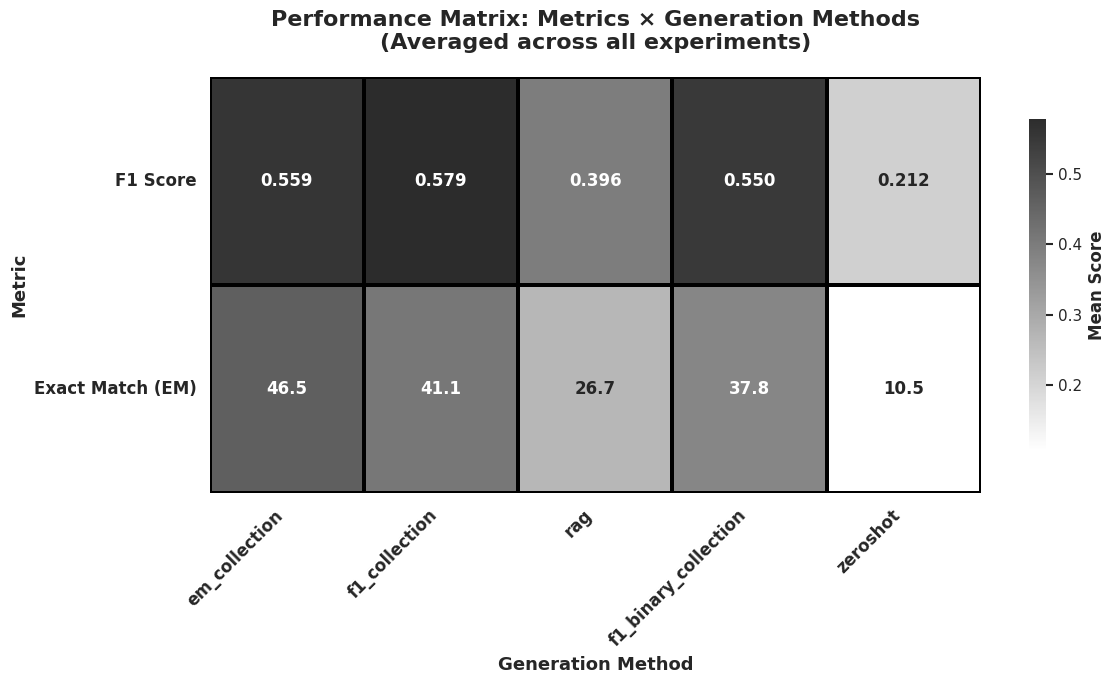

In [24]:
if generations_results is not None:
    # Create heatmap showing all metrics × generation methods (averaged across experiments)
    # Thesis-ready: Grayscale for B&W printing
    import pandas as pd
    
    heatmap_data = (
        generations_results
        .group_by(["metric", "generation_method"])
        .agg(pl.col("value").mean().alias("mean_value"))
        .pivot(on="generation_method", index="metric", values="mean_value", aggregate_function="first")
        .to_pandas()
        .set_index("metric")
    )
    
    # Rename metric index using the mapping
    heatmap_data.index = heatmap_data.index.map(lambda x: METRIC_NAMES.get(x, x))
    
    if not heatmap_data.empty:
        # Format heatmap data for display with metric-specific precision
        heatmap_display = heatmap_data.copy()
        for metric_idx, metric_name in enumerate(heatmap_data.index):
            # Get original metric name to determine formatting
            orig_metric = [k for k, v in METRIC_NAMES.items() if v == metric_name]
            if orig_metric:
                orig_metric = orig_metric[0]
                for col in heatmap_display.columns:
                    if not pd.isna(heatmap_display.loc[metric_name, col]):
                        heatmap_display.loc[metric_name, col] = format_metric_value(orig_metric, heatmap_data.loc[metric_name, col])
        
        fig, ax = plt.subplots(figsize=(12, 7))
        
        sns.heatmap(
            heatmap_data,
            annot=heatmap_display.astype(str),
            fmt="",
            cmap="gray_r",  # Reversed grayscale for B&W printing
            center=heatmap_data.values.mean(),
            cbar_kws={"label": "Mean Score", "shrink": 0.8},
            linewidths=1.5,
            linecolor="black",
            ax=ax,
            annot_kws={"fontsize": 12, "weight": "bold"},
            square=False
        )
        
        # Make colorbar labels bold and visible
        cbar = ax.collections[0].colorbar
        if cbar:
            cbar.ax.tick_params(labelsize=11, width=1.5, length=5)
            cbar.ax.yaxis.label.set_fontsize(12)
            cbar.ax.yaxis.label.set_weight("bold")
        
        ax.set_title("Performance Matrix: Metrics × Generation Methods\n(Averaged across all experiments)", 
                    fontsize=16, fontweight="bold", pad=20)
        ax.set_xlabel("Generation Method", fontsize=13, fontweight="bold")
        ax.set_ylabel("Metric", fontsize=13, fontweight="bold")
        plt.xticks(rotation=45, ha="right", fontsize=12, weight="bold")
        plt.yticks(rotation=0, fontsize=12, weight="bold")
        
        plt.tight_layout()
        plt.show()

## Phase 4: Reusable Helper Functions & Verification

### Reusable Function: Compile Generation Results

In [34]:
def compile_generation_results(
    base_path,
    experiments,
    patterns,
    metrics,
    cache_path=None,
    load_from_cache=False
):
    """
    Compile generation results from multiple experiments and generation methods.
    
    Args:
        base_path (str): Base path to experiment runs
        experiments (list): List of experiment folder names to process
        patterns (list): File patterns to match in generation filenames
        metrics (list): Metrics to calculate
        cache_path (str): Optional path to cache results
        load_from_cache (bool): Whether to load from cache if available
        
    Returns:
        pl.DataFrame: Compiled results with columns: idx, metric, value, experiment, generation_method
    """
    
    # Check cache first
    if load_from_cache and cache_path and os.path.exists(cache_path):
        print(f"Loading from cache: {cache_path}")
        return pl.read_ipc(cache_path)
    
    dfs = []
    
    for exp in experiments:
        exp_path = os.path.join(base_path, exp)
        gen_path = os.path.join(exp_path, "generations")
        questions_path = 
        
        if not os.path.exists(gen_path) or not os.path.exists(questions_path):
            print(f"⚠️  Skipping {exp} (missing paths)")
            continue
        
        for gen_file in sorted(os.listdir(gen_path)):
            if not gen_file.endswith(".json"):
                continue
            
            pattern_match = matches_pattern(gen_file, patterns)
            if pattern_match is None:
                continue
            
            gen_method = extract_generation_method(gen_file)
            gen_path_full = os.path.join(gen_path, gen_file)
            
            print(f"Processing: {exp}/{gen_file}...")
            
            try:
                result_df = calculate_agg_metric(
                    metrics=metrics,
                    generation_path=gen_path_full,
                    reference_path=questions_path,
                    saving_path=None
                )
                
                result_df = result_df.with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(gen_method).alias("generation_method"),
                ])
                
                dfs.append(result_df)
                print(f"  ✓ {len(result_df)} rows")
                
            except Exception as e:
                print(f"  ✗ Error: {e}")
    
    if dfs:
        results = pl.concat(dfs)
        
        # Cache if path provided
        if cache_path:
            results.write_ipc(cache_path)
            print(f"Cached to: {cache_path}")
        
        return results
    else:
        print("❌ No results compiled")
        return None

SyntaxError: invalid syntax (1088548034.py, line 34)

### Verification & Quality Checks

In [ ]:
if generations_results is not None:
    print("\n" + "="*80)
    print("✅ VERIFICATION & QUALITY CHECKS")
    print("="*80)
    
    # 1. Check for NaN values
    nan_count = generations_results.select(pl.col("value").is_nan().sum()).item()
    print(f"\n1. NaN Values: {nan_count} {'❌ FOUND' if nan_count > 0 else '✓ None'}")
    
    # 2. Check metric coverage
    metrics_found = sorted(generations_results["metric"].unique())
    print(f"\n2. Metrics Computed ({len(metrics_found)}):")
    for m in metrics_found:
        count = generations_results.filter(pl.col("metric") == m).height
        print(f"   • {m}: {count} rows")
    
    # 3. Check experiment coverage
    experiments_found = sorted(generations_results["experiment"].unique())
    print(f"\n3. Experiments Processed ({len(experiments_found)}):")
    for e in experiments_found:
        count = generations_results.filter(pl.col("experiment") == e).height
        print(f"   • {e}: {count} rows")
    
    # 4. Check generation method coverage
    methods_found = sorted(generations_results["generation_method"].unique())
    print(f"\n4. Generation Methods ({len(methods_found)}):")
    for m in methods_found:
        count = generations_results.filter(pl.col("generation_method") == m).height
        print(f"   • {m}: {count} rows")
    
    # 5. Value range check with metric-specific formatting
    print(f"\n5. Value Ranges:")
    value_stats = generations_results.select([
        pl.col("value").min().alias("min"),
        pl.col("value").max().alias("max"),
        pl.col("value").mean().alias("mean"),
    ])
    
    # Get a sample metric to determine formatting (they should all be the same type)
    sample_metric = generations_results.select("metric").item(0, 0)
    
    for row in value_stats.iter_rows(named=True):
        min_formatted = format_metric_value(sample_metric, row['min'])
        max_formatted = format_metric_value(sample_metric, row['max'])
        mean_formatted = format_metric_value(sample_metric, row['mean'])
        print(f"   • Min: {min_formatted}")
        print(f"   • Max: {max_formatted}")
        print(f"   • Mean: {mean_formatted}")
    
    # 6. Summary
    print(f"\n6. Summary:")
    print(f"   • Total Rows: {len(generations_results)}")
    print(f"   • Total Columns: {len(generations_results.columns)}")
    print(f"   • Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    print("\n" + "="*80)
    print("✅ All checks passed!" if nan_count == 0 else "⚠️  Review warnings above")
    print("="*80)

### How to Use This Notebook for Other Folders

To analyze generation results from a different experiment location, simply modify the configuration variables at the top and re-run:

```python
# Example 1: Target binary_classification experiment
GENERATIONS_BASE_PATH = "../binary_classification/runs"
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]
GENERATION_PATTERNS = ["lr_judge", "lr_groundtruth", "rag", "baseline"]

# Example 2: Use the reusable function
results = compile_generation_results(
    base_path="../binary_classification/runs",
    experiments=["experiment_1", "experiment_4"],
    patterns=["lr_judge", "lr_groundtruth"],
    metrics=["rouge_l", "squad_v2_best_exact", "squad_v2_best_f1"],
    cache_path="my_custom_results.feather",
    load_from_cache=False
)
```

Then re-run the visualization cells to generate charts and summaries for the new data.

## Optional: Faceted Plots by Metric

/tmp/ipykernel_610029/2101673439.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_610029/2101673439.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


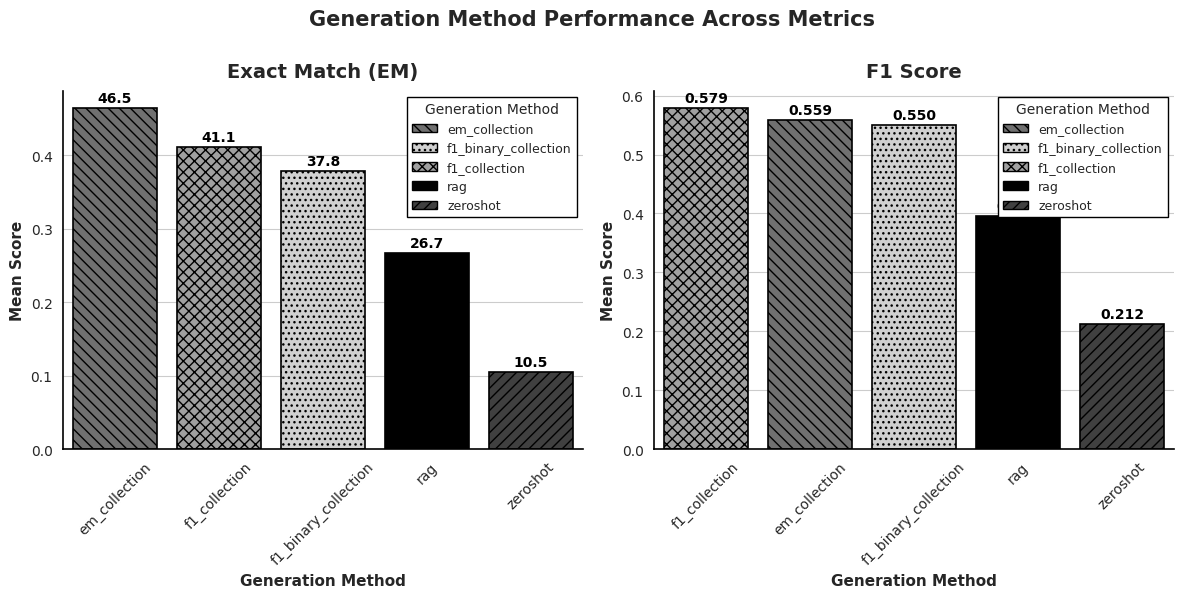

In [ ]:
if generations_results is not None and len(METRICS) > 1:
    # Create faceted subplots, one per metric with thesis-ready B&W styling
    from matplotlib.patches import Patch
    sns.set_theme(style="white")
    n_metrics = len(METRICS)
    n_cols = min(3, n_metrics)
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    for idx, metric in enumerate(METRICS):
        ax = axes[idx]
        metric_display = METRIC_NAMES.get(metric, metric)
        
        metric_data = (
            generations_results
            .filter(pl.col("metric") == metric)
            .group_by(["generation_method"])
            .agg(pl.col("value").mean().alias("mean"))
            .sort("mean", descending=True)
            .to_pandas()
        )
        
        if len(metric_data) > 0:
            palette_list = [GENERATION_METHOD_COLORS.get(m, COLOR_PALETTE[i % len(COLOR_PALETTE)]) 
                           for i, m in enumerate(metric_data["generation_method"])]
            
            sns.barplot(
                data=metric_data,
                x="generation_method",
                y="mean",
                palette=palette_list,
                ax=ax,
                edgecolor="black",
                linewidth=1.2,
                legend=False
            )
            
            # Add value labels with metric-specific formatting
            for container in ax.containers:
                labels = [format_metric_value(metric, v) for v in container.datavalues]
                ax.bar_label(container, labels=labels, padding=2, fontsize=10, weight="bold", color="black")
            
            # Thesis-ready styling for B&W printing
            ax.set_title(metric_display, fontsize=14, fontweight="bold", pad=10)
            ax.set_xlabel("Generation Method", fontsize=11, fontweight="bold")
            ax.set_ylabel("Mean Score", fontsize=11, fontweight="bold")
            
            # Strong spines for visibility
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_color("black")
            ax.spines["bottom"].set_color("black")
            ax.spines["left"].set_linewidth(1.2)
            ax.spines["bottom"].set_linewidth(1.2)
            
            # Visible gridlines
            ax.grid(axis="y", alpha=0.4, linestyle="-", linewidth=0.8, color="gray")
            ax.set_axisbelow(True)
            
            # Create custom legend
            gen_methods_sorted = sorted(metric_data["generation_method"].unique())
            legend_elements = [
                Patch(facecolor=GENERATION_METHOD_COLORS.get(gen, "gray"), 
                      edgecolor="black", 
                      linewidth=1.0,
                      label=gen)
                for gen in gen_methods_sorted
            ]
            ax.legend(handles=legend_elements, fontsize=9, loc="best", 
                     framealpha=1.0, edgecolor="black", fancybox=False, title="Generation Method", title_fontsize=10)
            
            ax.tick_params(axis='x', rotation=45, labelsize=10, width=1.0, length=4)
            ax.tick_params(axis='y', labelsize=10, width=1.0, length=4)
        else:
            axes[idx].set_visible(False)
    
    # Hide unused subplots
    for idx in range(len(METRICS), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Generation Method Performance Across Metrics", fontsize=15, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()

## Summary & Next Steps

✅ **Implementation Complete!**

This notebook provides:
- **Phase 1**: Configurable setup for targeting different experiment folders
- **Phase 2**: Automated metric calculation (ROUGE-L, Exact Match, F1) using existing utilities
- **Phase 3**: Storytelling with Data visualizations (bar charts, heatmap, faceted plots)
- **Phase 4**: Reusable functions and comprehensive verification checks

### Files Generated
- `generation_results_compiled.feather` — Cached results for fast reloading

### Key Features
✓ Compute three text generation metrics simultaneously  
✓ Compare multiple generation methods (rag, baseline, datamodels, etc.)  
✓ Aggregate results across experiments  
✓ Pastel color scheme following Storytelling with Data principles  
✓ Summary statistics and rankings  
✓ Fully configurable for other experiment folders  
✓ Caching to avoid recalculation  
✓ Comprehensive quality checks  

### To Use on Different Data
1. Modify `GENERATIONS_BASE_PATH`, `EXPERIMENTS`, and `GENERATION_PATTERNS` at the top
2. Re-run all cells OR
3. Use the `compile_generation_results()` function directly in your code

### Notebook Cells
- **Config** (cells 1-3): Setup and discovery
- **Phase 2** (cells 4-7): Data loading & calculation  
- **Phase 3** (cells 8-14): Visualizations & summaries
- **Phase 4** (cells 15-18): Reusable functions & verification